<a href="https://colab.research.google.com/github/vaishnavidangi704-commits/CSL701-11_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [19]:
import numpy as np
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [20]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/card_transdata.csv")

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("Number of rows and columns:", df.shape)

# Display column names and data types
print("\nColumn information:")
print(df.dtypes)

# Display numerical columns
print("\nNumerical attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())

# Display categorical columns
print("\nCategorical attributes:")
print(df.select_dtypes(include="object").columns.tolist())

# Separate target variable
y = df["fraud"] # Changed from 'Selling_Price' to 'fraud'

print("\nTarget variable:")
print("fraud") # Changed from 'Selling_Price' to 'fraud'

First 5 records:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


Number of rows and columns: (1000000, 8)

Column information:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Numerical attributes:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

Categorical attributes:
[]

Target variable:
fraud


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [21]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Remove rows containing missing values, if any
df = df.dropna()

# Verify that there are no missing values
print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)

Missing values in each column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Total missing values: 0

Missing values after handling:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Final dataset shape: (1000000, 8)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [22]:
# Select all columns except the target variable
feature_columns = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price",
    "repeat_retailer",
    "used_chip",
    "used_pin_number",
    "online_order"
]

X = df[feature_columns].copy()
y = df["fraud"].copy()

print("Selected features:")
print(feature_columns)

print("\nFeature matrix:")
display(X.head())

print("\nTarget:")
display(y.head())

Selected features:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Feature matrix:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0



Target:


,fraud
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [23]:
# Check categorical columns
categorical_columns = X.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

if len(categorical_columns) > 0:
    X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("\nAll predictors are numerical:")
print(X.dtypes)

print("\nTransformed dataset:")
display(X.head())

Categorical columns:
[]

All predictors are numerical:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
dtype: object

Transformed dataset:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [24]:
# Create a combined distance feature
X["total_transaction_distance"] = (
    X["distance_from_home"] +
    X["distance_from_last_transaction"]
)

print("New feature created: total_transaction_distance")

display(X.head())

print("\nUpdated features:")
print(X.columns.tolist())

New feature created: total_transaction_distance


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,total_transaction_distance
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,58.188997
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,11.005534
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,5.896232
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,7.847608
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,44.757422



Updated features:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'total_transaction_distance']


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

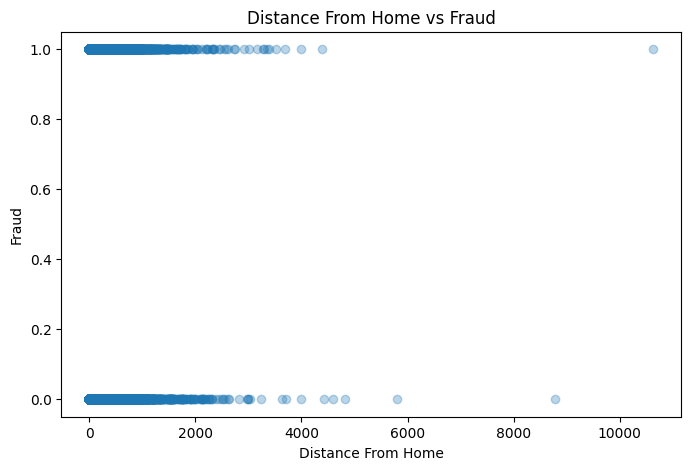

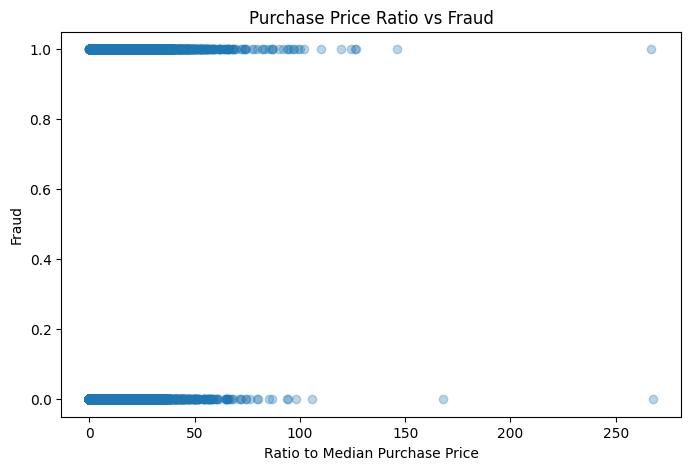

In [25]:
# Plot 1
plt.figure(figsize=(8, 5))
plt.scatter(
    df["distance_from_home"],
    y,
    alpha=0.3
)
plt.xlabel("Distance From Home")
plt.ylabel("Fraud")
plt.title("Distance From Home vs Fraud")
plt.show()

# Plot 2
plt.figure(figsize=(8, 5))
plt.scatter(
    df["ratio_to_median_purchase_price"],
    y,
    alpha=0.3
)
plt.xlabel("Ratio to Median Purchase Price")
plt.ylabel("Fraud")
plt.title("Purchase Price Ratio vs Fraud")
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [30]:
# Calculate mean and standard deviation
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

# Standardize training data
X_train_scaled = (X_train - X_mean) / X_std

# Standardize testing data using training mean and std
X_test_scaled = (X_test - X_mean) / X_std

print("Training data after standardization:")
display(X_train_scaled.head())

print("\nTraining means:")
print(X_mean)

print("\nTraining standard deviations:")
print(X_std)

Training data after standardization:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,total_transaction_distance
566853,0.147170,-0.181191,-0.588185,0.366618,1.361703,-0.334593,0.732884,0.068505
382311,-0.091174,-0.168859,-0.415652,0.366618,1.361703,-0.334593,0.732884,-0.147853
241519,-0.334813,-0.100009,0.612860,0.366618,1.361703,-0.334593,0.732884,-0.347926
719220,-0.317543,-0.143624,-0.551591,0.366618,-0.734374,-0.334593,0.732884,-0.348269
905718,0.077164,-0.126583,-0.590736,0.366618,-0.734374,-0.334593,-1.364471,0.024076



Training means:
distance_from_home                26.619659
distance_from_last_transaction     5.026863
ratio_to_median_purchase_price     1.825205
repeat_retailer                    0.881516
used_chip                          0.350356
used_pin_number                    0.100681
online_order                       0.650567
total_transaction_distance        31.646521
dtype: float64

Training standard deviations:
distance_from_home                65.213843
distance_from_last_transaction    26.375663
ratio_to_median_purchase_price     2.794690
repeat_retailer                    0.323180
used_chip                          0.477082
used_pin_number                    0.300906
online_order                       0.476791
total_transaction_distance        70.337573
dtype: float64


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [28]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of observations in the training set: {X_train.shape[0]}")
print(f"Number of observations in the testing set: {X_test.shape[0]}")

Number of observations in the training set: 800000
Number of observations in the testing set: 200000


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [32]:
Xtrain = X_train.to_numpy()
ytrain = y_train.to_numpy().reshape(-1, 1)

Xtest = X_test.to_numpy()
ytest = y_test.to_numpy().reshape(-1, 1)

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

Xtrain shape: (800000, 8)
ytrain shape: (800000, 1)
Xtest shape: (200000, 8)
ytest shape: (200000, 1)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [33]:
# Add a column of ones for the intercept
Xtrain_bias = np.column_stack(
    (np.ones(Xtrain.shape[0]), Xtrain)
)

Xtest_bias = np.column_stack(
    (np.ones(Xtest.shape[0]), Xtest)
)

print("Xtrain with bias:", Xtrain_bias.shape)
print("Xtest with bias:", Xtest_bias.shape)

print("\nFirst row of Xtrain:")
print(Xtrain_bias[0])

Xtrain with bias: (800000, 9)
Xtest with bias: (200000, 9)

First row of Xtrain:
[ 1.         36.21718306  0.24783829  0.18141074  1.          1.
  0.          1.         36.46502136]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [34]:
def ordinary_least_squares(X, y):
    # Calculate X transpose
    XT = X.T

    # Calculate X^T X
    XTX = XT @ X

    # Calculate X^T y
    XTy = XT @ y

    # Calculate beta
    beta = np.linalg.inv(XTX) @ XTy

    return beta


# Train the model
beta = ordinary_least_squares(Xtrain_bias, ytrain)

print("Regression coefficients:")
print(beta)

Regression coefficients:
[[-0.07830894]
 [-0.00058838]
 [-0.00050799]
 [ 0.04689751]
 [-0.02586614]
 [-0.03627138]
 [-0.09409335]
 [ 0.11388911]
 [ 0.0014816 ]]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [35]:
# Calculate X transpose X
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant
determinant = np.linalg.det(XTX)

print("Determinant of XTX:")
print(determinant)

if np.isclose(determinant, 0):
    print("\nXTX is singular or nearly singular.")
else:
    print("\nXTX is not singular.")

Determinant of XTX:
-1.7939630868138955e+46

XTX is not singular.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [36]:
beta = ordinary_least_squares(Xtrain_bias, ytrain)

print("Intercept (β0):")
print(beta[0][0])

print("\nFeature coefficients:")

for feature, coefficient in zip(X.columns, beta[1:]):
    print(f"{feature}: {coefficient[0]}")

Intercept (β0):
-0.07830893732384275

Feature coefficients:
distance_from_home: -0.0005883822633694043
distance_from_last_transaction: -0.0005079862936090349
ratio_to_median_purchase_price: 0.046897514528919645
repeat_retailer: -0.025866138259220944
used_chip: -0.036271379760771945
used_pin_number: -0.09409334573249892
online_order: 0.11388910958658412
total_transaction_distance: 0.0014815960778901433


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [37]:
print("Coefficient interpretation:\n")

for feature, coefficient in zip(X.columns, beta[1:]):
    value = coefficient[0]

    if value > 0:
        direction = "positive"
    elif value < 0:
        direction = "negative"
    else:
        direction = "zero"

    print(f"{feature}: {value:.6f} ({direction})")

Coefficient interpretation:

distance_from_home: -0.000588 (negative)
distance_from_last_transaction: -0.000508 (negative)
ratio_to_median_purchase_price: 0.046898 (positive)
repeat_retailer: -0.025866 (negative)
used_chip: -0.036271 (negative)
used_pin_number: -0.094093 (negative)
online_order: 0.113889 (positive)
total_transaction_distance: 0.001482 (positive)


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [38]:
# Predict using the trained coefficients
y_pred = Xtest_bias @ beta

print("Sample actual vs predicted values:")

comparison = pd.DataFrame({
    "Actual Fraud": ytest.flatten()[:20],
    "Predicted Fraud": y_pred.flatten()[:20]
})

display(comparison)

Sample actual vs predicted values:


,Actual Fraud,Predicted Fraud
0,0.0,0.054608
1,0.0,0.182597
2,0.0,-0.026031
3,0.0,0.450740
4,0.0,-0.004404
5,0.0,-0.082466
6,0.0,0.127458
7,0.0,-0.017675
8,0.0,0.042643
9,1.0,0.156074


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [39]:
# Calculate residuals
errors = ytest - y_pred

# Calculate RSS
RSS = np.sum(errors ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nLower RSS indicates smaller overall prediction error.")

Residual Sum of Squares (RSS):
11171.826889287022

Lower RSS indicates smaller overall prediction error.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [40]:
# Calculate Total Sum of Squares
y_mean = np.mean(ytest)

TSS = np.sum((ytest - y_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR²:")
print(R2)

Total Sum of Squares (TSS):
15921.708754999998

R²:
0.2983273930457583


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


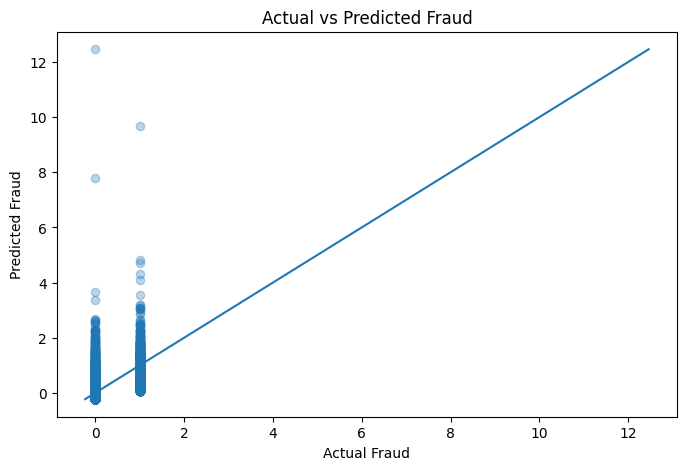

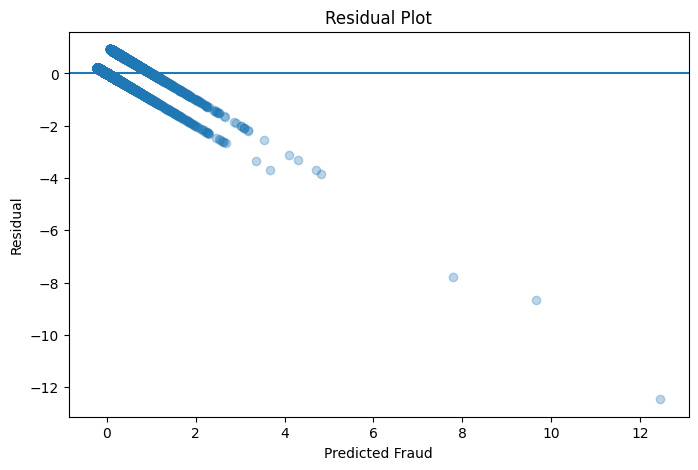

In [41]:
# Actual vs Predicted
plt.figure(figsize=(8, 5))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.3
)

# Perfect prediction line
minimum = min(ytest.min(), y_pred.min())
maximum = max(ytest.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Fraud")
plt.ylabel("Predicted Fraud")
plt.title("Actual vs Predicted Fraud")
plt.show()


# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    errors,
    alpha=0.3
)

plt.axhline(0)

plt.xlabel("Predicted Fraud")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.